# Task 3: Prediction of perturbation effect

In [1]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pathlib import Path
import numpy as np
import pandas as pd

import scanpy as sc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from scmlcourse.perturbation import *

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
data_dir = Path("../../data")

### Data Loading


In [3]:
data_module = DataModule(data_dir/"qced_data.h5ad", n_workers=4, n_top_genes=1000, retain_adata = True)

/omics/groups/OE0436/data/ntoulouse/scMLCourse/src/scmlcourse/perturbation.py:82: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  self.adata.layers["raw"] = self.adata.X.copy()


Co-culture cell_name
CELL_145219      CCND2_Co-culture
CELL_145220       CD44_Co-culture
CELL_145221    control_Co-culture
CELL_145223    control_Co-culture
CELL_145226      JMJD7_Co-culture
                      ...        
CELL_218327       CTSO_Co-culture
CELL_218328       JAK2_Co-culture
CELL_218329    control_Co-culture
CELL_218330     CDKN2B_Co-culture
CELL_218331    control_Co-culture
Name: perturbed_condition, Length: 35063, dtype: str


/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.

            group   names    scores  logfoldchanges     pvals  pvals_adj
0  A2M_Co-culture   CCNL1  3.534528        0.807921  0.000409   0.424436
1  A2M_Co-culture   CENPF  2.658174        0.593586  0.007857   1.000000
2  A2M_Co-culture   CKS1B  2.491435        0.476076  0.012723   1.000000
3  A2M_Co-culture  FAM83D  2.445000        0.614838  0.014485   1.000000
4  A2M_Co-culture   CLSPN  2.383212        0.528831  0.017162   1.000000
Control cell_name
CELL_5         control_Control
CELL_6          IFNGR1_Control
CELL_7        C6orf226_Control
CELL_8          CDKN1A_Control
CELL_9            EMP1_Control
                    ...       
CELL_57618     control_Control
CELL_57620     control_Control
CELL_57623     control_Control
CELL_57625     control_Control
CELL_57627     control_Control
Name: perturbed_condition, Length: 28091, dtype: str


/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.

         group    names    scores  logfoldchanges     pvals  pvals_adj
0  A2M_Control    MKNK2  3.038503        0.662412  0.002378        1.0
1  A2M_Control   PARP14  2.753513        0.701850  0.005896        1.0
2  A2M_Control     ATF5  2.683735        0.549061  0.007280        1.0
3  A2M_Control  SPANXB1  2.558948        0.280484  0.010499        1.0
4  A2M_Control      IL6  2.479546        0.655069  0.013155        1.0
IFNγ cell_name
CELL_57628      control_IFNγ
CELL_57629        CSPG4_IFNγ
CELL_57630      control_IFNγ
CELL_57631      control_IFNγ
CELL_57632      control_IFNγ
                   ...      
CELL_145210    C19orf48_IFNγ
CELL_145211     control_IFNγ
CELL_145212     control_IFNγ
CELL_145213       AEBP1_IFNγ
CELL_145214     control_IFNγ
Name: perturbed_condition, Length: 43797, dtype: str


/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.

      group  names    scores  logfoldchanges     pvals  pvals_adj
0  A2M_IFNγ  CLSPN  3.996953        0.809364  0.000064   0.066665
1  A2M_IFNγ  HMGB2  3.507424        0.779745  0.000452   0.235057
2  A2M_IFNγ   TUBB  3.396550        0.246461  0.000682   0.236342
3  A2M_IFNγ  MKI67  3.301486        0.750485  0.000962   0.249812
4  A2M_IFNγ  CENPF  3.059043        0.718334  0.002220   0.377957
logfoldchanges has shape (1039, 150)
['CD274_Co-culture', 'CD274_Control', 'CD274_IFNγ', 'IFNGR2_Co-culture', 'IFNGR2_Control', 'IFNGR2_IFNγ', 'CCND2_Co-culture', 'CCND2_Control', 'CCND2_IFNγ', 'CMSS1_Co-culture', 'CMSS1_Control', 'CMSS1_IFNγ', 'CD59_Co-culture', 'CD59_Control', 'CD59_IFNγ', 'CYP27A1_Co-culture', 'CYP27A1_Control', 'CYP27A1_IFNγ', 'IDH2_Co-culture', 'IDH2_Control', 'IDH2_IFNγ', 'CDKN1A_Co-culture', 'CDKN1A_Control', 'CDKN1A_IFNγ', 'CD58_Co-culture', 'CD58_Control', 'CD58_IFNγ', 'HLA-A_Co-culture', 'HLA-A_Control', 'HLA-A_IFNγ'] ['control_Co-culture', 'control_Control', 'control_IF

In [4]:
print(
    data_module.adata,
    data_module.n_vars,
    data_module.batch_size,
    sep="\n------\n")

View of AnnData object with n_obs × n_vars = 106951 × 1039
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'perturbed_gene', 'perturbed_condition'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hi

## Simplistic Baseline: Small MLP

In [5]:
data_module.adata.obs["train_set"] = data_module.adata.obs["perturbed_condition"].map(lambda x: x in data_module.train_genes)
data_module.adata.obs[["perturbed_gene", "perturbation_2", "train_set"]].value_counts().reset_index().pivot(index="perturbed_gene", columns=["perturbation_2", "train_set"])

/tmp/ipykernel_610757/1034738237.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  data_module.adata.obs["train_set"] = data_module.adata.obs["perturbed_condition"].map(lambda x: x in data_module.train_genes)


count                                            
perturbation_2   IFNγ Co-culture Control Co-culture  IFNγ Control
train_set       True       True    True       False False   False
perturbed_gene                                                   
A2M               514        412     351          0     0       0
ACTA2             590        428     384          0     0       0
AEBP1             518        376     371          0     0       0
AGA               411        369     305          0     0       0
AHNAK             424        294     309          0     0       0
APOD              453        341     287          0     0       0
APOE              447        343     305          0     0       0
ATP1B1            443        317     331          0     0       0
B2M               524        456     344          0     0       0
BZW2              364        308     269          0     0       0
C6orf226          405        318     258          0     0       0
C19orf48          442        358     288          0     0       0
CCND2               0          0       0        322   397     266
CCR10             391        309     250          0     0       0
CD44              432        406     329          0     0       0
CD47              418        292     284          0     0       0
CD58                0          0       0        446   406     280
CD59                0          0       0        393   510     302
CD151             362        335     267          0     0       0
CD274               0          0       0        358   507     323
CDH19             454        367     321          0     0       0
CDKN1A              0          0       0        342   389     286
CDKN2B            409        303     247          0     0       0
CHCHD2            418        321     244          0     0       0
CITED1            413        340     330          0     0       0
CKS1B             402        281     253          0     0       0
CMSS1               0          0       0        328   395     253
CSPG4             456        382     315          0     0       0
CTSA              362        282     274          0     0       0
CTSB              424        360     273          0     0       0
CTSD              472        390     318          0     0       0
CTSL              352        284     262          0     0       0
CTSO              416        308     283          0     0       0
CYP27A1             0          0       0        303   352     268
DLL3              366        278     244          0     0       0
EMP1              375        288     260          0     0       0
FBXO32            391        374     244          0     0       0
FGFR1             464        383     309          0     0       0
FMN1              419        307     258          0     0       0
FSTL3             407        333     269          0     0       0
GSN               354        305     271          0     0       0
HLA-A               0          0       0        321   381     251
HLA-DRB5          406        345     258          0     0       0
IDH2                0          0       0        343   350     248
IFNGR1            287        406     196          0     0       0
IFNGR2              0          0       0        579   380     212
JAK1              334        458     208          0     0       0
JAK2              336        515     238          0     0       0
JMJD7             360        342     199          0     0       0
MFGE8             422        318     230          0     0       0
control         23093      17396   14166          0     0       0

In [6]:
from pytorch_lightning.loggers import CSVLogger
log_dir = Path("../logs")
log_dir.mkdir(exist_ok=True)

In [7]:
mlp_config = dict(
    in_dim=data_module.n_vars,
    out_dim=data_module.n_vars,
    hidden_dims=(data_module.n_vars,)*3,
)
baseline_model = Baseline(mlp_config, lr=0.001)

In [8]:
baseline_model, baseline_test_scores, baseline_logged_dir = train(
    baseline_model,
    data_module,
    max_epochs = 1000,
    patience = 15,
    log_dir = "logs",
    run_name = "baseline",
    seed = 0,
)
import gc
gc.collect()

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Training for max 1000 epochs...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name   | Type    | Params | Mode  | FLOPs
---------------------------------------------------
0 | module | MLP     | 4.3 M  | train | 0    
1 | loss   | MSELoss | 0      | train | 0    
---------------------------------------------------
4.3 M     Trainable params
0         Non-trainable params
4.3 M     Total params
17.289    Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/n

...

Monitored metric val_loss did not improve in the last 15 records. Best score: 32.125. Signaling Trainer to stop.


Epoch 18: 100%|██████████| 872/872 [00:03<00:00, 228.62it/s, v_num=9, train_loss_step=20.80, val_loss=34.20, val_pearson=0.269, train_loss_epoch=27.20]


Restoring states from the checkpoint path at /omics/groups/OE0436/data/ntoulouse/scMLCourse/notebooks/logs/baseline/version_9/epoch=3-val_loss=32.1253.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /omics/groups/OE0436/data/ntoulouse/scMLCourse/notebooks/logs/baseline/version_9/epoch=3-val_loss=32.1253.ckpt
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use 

Testing DataLoader 0: 100%|██████████| 102/102 [00:00<00:00, 443.17it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss            54.13432693481445
      test_pearson          0.6008532047271729
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


3601

In [9]:
logs = pd.read_csv(baseline_logged_dir+"/metrics.csv")
logs

,epoch,lr-Adam,step,test_loss,test_pearson,train_loss_epoch,train_loss_step,train_pearson,val_loss,val_pearson
0,NaN,0.001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,9,NaN,NaN,NaN,52.839779,NaN,NaN,NaN
2,0.0,NaN,19,NaN,NaN,NaN,39.240276,NaN,NaN,NaN
3,0.0,NaN,29,NaN,NaN,NaN,44.181618,NaN,NaN,NaN
4,0.0,NaN,39,NaN,NaN,NaN,33.361546,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1709,18.0,NaN,16549,NaN,NaN,NaN,26.587383,NaN,NaN,NaN
1710,18.0,NaN,16559,NaN,NaN,NaN,30.740068,NaN,NaN,NaN
1711,18.0,NaN,16567,NaN,NaN,NaN,NaN,NaN,34.213654,0.268874
1712,18.0,NaN,16567,NaN,NaN,27.195404,NaN,0.27003,NaN,NaN


array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>]], dtype=object)

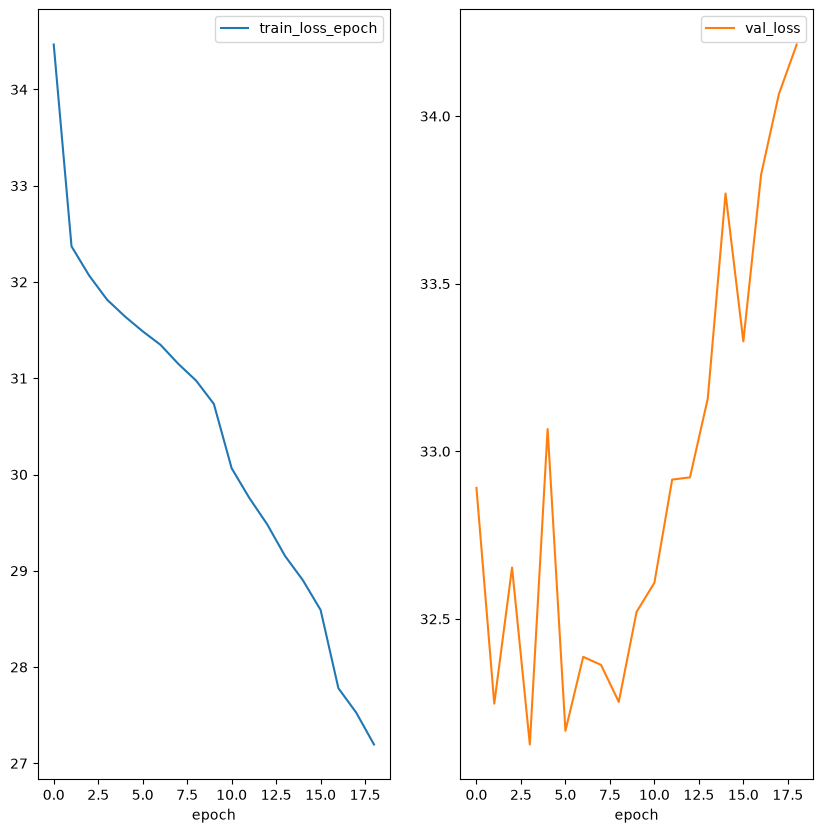

In [12]:
plot_cols = ["train_loss_epoch", "val_loss", ]
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(-1,2), figsize=(10,10))

In [7]:
in_dim=data_module.n_vars
latent_dim = 512
dropout=0.1
encoder_kwargs = dict(
    hidden_dims=(in_dim, in_dim, in_dim, latent_dim, latent_dim),
    dropout=0
)
decoder_kwargs = dict(
    hidden_dims=(latent_dim+in_dim, in_dim, in_dim, in_dim, in_dim),
    dropout=dropout
)
cvae = cVAE(in_dim = in_dim, latent_dim=latent_dim, encoder_kwargs = encoder_kwargs, decoder_kwargs = decoder_kwargs, lr=0.00001, kl_midpoint=10)


{'hidden_dims': (1039, 1039, 1039, 512, 512), 'dropout': 0, 'in_dim': 1039, 'out_dim': 512, 'out_activation': None}
{'hidden_dims': (1039, 1039, 1039, 512, 512), 'dropout': 0, 'in_dim': 1039, 'out_dim': 512, 'out_activation': None}
{'hidden_dims': (1551, 1039, 1039, 1039, 1039), 'dropout': 0.1, 'out_dim': 1039, 'in_dim': 1551, 'out_activation': <class 'torch.nn.modules.activation.ReLU'>}


In [8]:
model, test_scores, logged_dir = train(
    cvae,
    data_module,
    max_epochs = 50,
    patience = 100,
    log_dir = log_dir,
    run_name = "cvae",
    seed = 0,
)
import gc
gc.collect()

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Training for max 50 epochs...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type    | Params | Mode  | FLOPs
----------------------------------------------------------
0 | module        | MLP     | 8.3 M  | train | 0    
1 | loss          | MSELoss | 0      | train | 0    
2 | mu_encoder    | MLP     | 4.3 M  | train | 0    
3 | sigma_encoder | MLP     | 4.3 M  | train | 0    
----------------------------------------------------------
16.9 M    Trainable params
0         Non-trainable params
16.9 M    Total params
67.763    Total estimated model params size (MB)
56        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/n

...

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 869/869 [00:08<00:00, 103.06it/s, v_num=12, train_loss_step=51.10, train_loss_kl_step=1.890, train_loss_mse_x_step=49.20, val_pearson=0.817, val_loss=25.20, val_loss_kl=1.200, val_loss_mse_x=24.00, kl_factor=1.000, lr=1e-5, train_pearson=0.814, train_loss_epoch=26.40, train_loss_kl_epoch=1.220, train_loss_mse_x_epoch=25.10]


Restoring states from the checkpoint path at /omics/groups/OE0436/data/ntoulouse/scMLCourse/logs/cvae/version_12/epoch=4-val_loss=24.1184.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /omics/groups/OE0436/data/ntoulouse/scMLCourse/logs/cvae/version_12/epoch=4-val_loss=24.1184.ckpt
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.versio

Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 271.75it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       pearson_fc          0.011890409514307976
        pearson_x           0.8199931979179382
        test_loss            113.4273910522461
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


2284

In [9]:
logs = pd.read_csv(logged_dir+"/metrics.csv")
logs

,epoch,kl_factor,lr,lr-Adam,pearson_fc,pearson_x,step,test_loss,train_latent_max,train_latent_mean,...,train_mu_mean,train_mu_min,train_pearson,train_x_hat_max,train_x_hat_mean,train_x_hat_min,val_loss,val_loss_kl,val_loss_mse_x,val_pearson
0,NaN,NaN,NaN,0.00001,NaN,NaN,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,19,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,NaN,NaN,NaN,NaN,29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4491,49.0,NaN,NaN,NaN,NaN,NaN,43439,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4492,49.0,NaN,NaN,NaN,NaN,NaN,43449,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4493,49.0,NaN,NaN,NaN,NaN,NaN,43449,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.19198,1.203973,23.988003,0.816826
4494,49.0,1.0,0.00001,NaN,NaN,NaN,43449,NaN,4.277179,0.005213,...,0.005139,-0.531395,0.813677,192.881592,0.941428,0.0,NaN,NaN,NaN,NaN


array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>]], dtype=object)

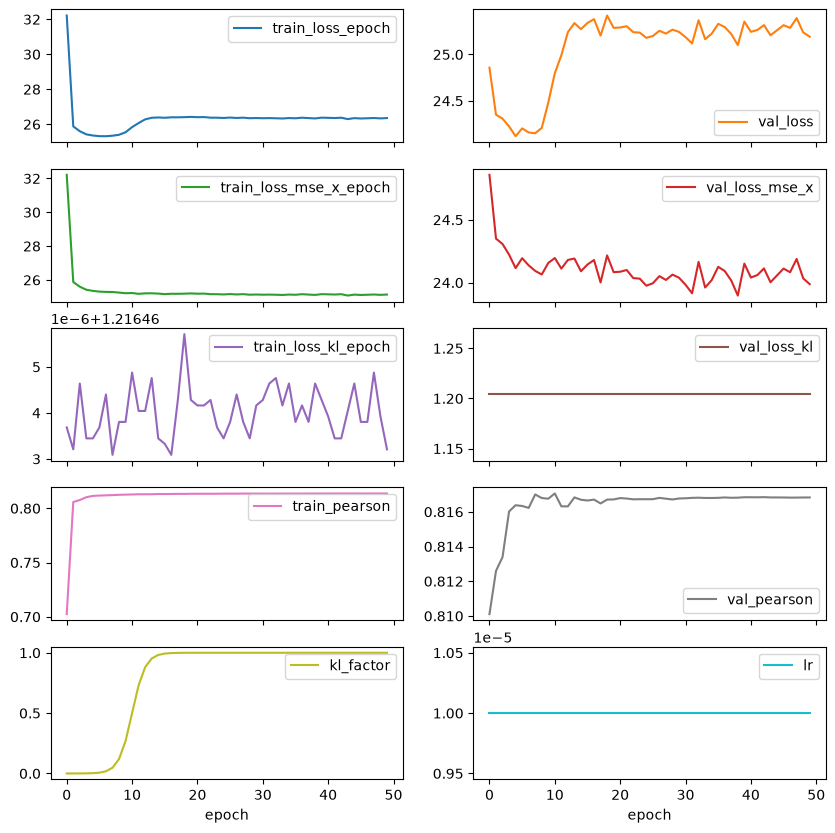

In [10]:
plot_cols = ["train_loss_epoch", "val_loss", "train_loss_mse_x_epoch", "val_loss_mse_x", "train_loss_kl_epoch", "val_loss_kl", "train_pearson", "val_pearson", "kl_factor", "lr"]
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(-1,2), figsize=(10,10))

array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>]], dtype=object)

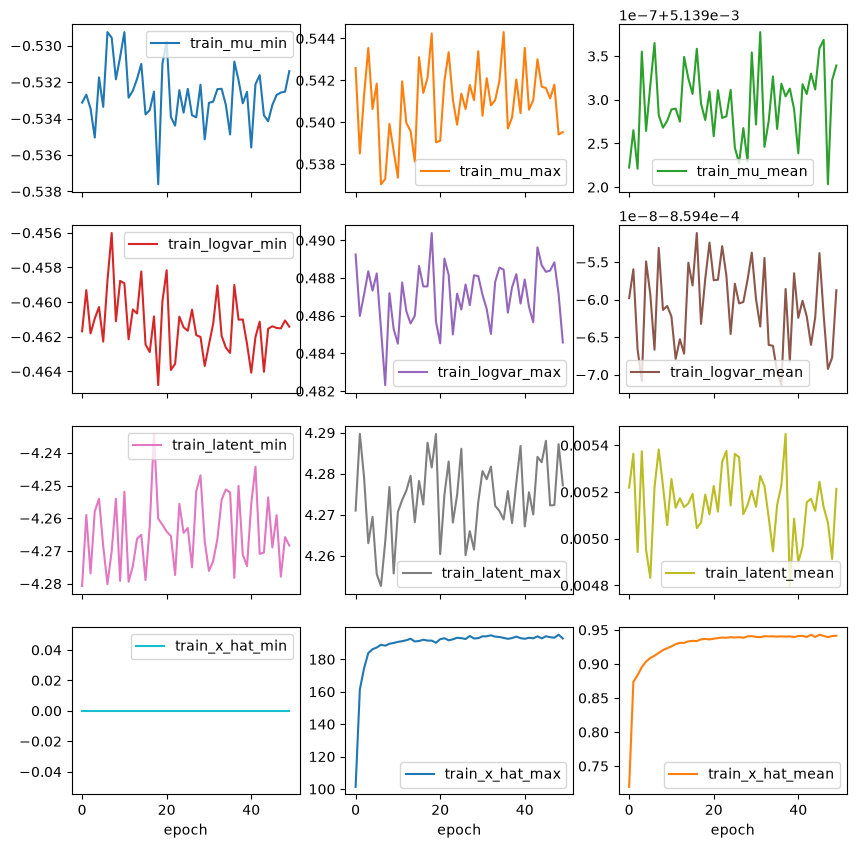

In [11]:
plot_cols = ["train_mu_min",
"train_mu_max",
"train_mu_mean",
"train_logvar_min",
"train_logvar_max",
"train_logvar_mean",
"train_latent_min",
"train_latent_max",
"train_latent_mean",
"train_x_hat_min",
"train_x_hat_max",
"train_x_hat_mean",]
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(4,3), figsize=(10,10))